<a href="https://colab.research.google.com/github/namvien94/uber-fare-prediction/blob/main/UberFarePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Uber Fare Prediction

## Project Objective

Build and compare regression models to predict Uber fares from trip location, time, and passenger information. The workflow covers data validation, geographic cleaning, feature engineering, model comparison, feature importance, selected-feature modeling, and LightGBM tuning.

### Key results from the original analysis
- **200,000** raw trip records
- **8 regression / machine-learning models** compared
- **LightGBM** achieved the best baseline RMSE
- Selected-feature LightGBM improved RMSE to approximately **3.75**
- Tuned LightGBM achieved a test RMSE of approximately **3.72**

> Lower Root Mean Squared Error (RMSE) indicates better predictive performance.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from IPython.display import display

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor
from xgboost import plot_importance
import lightgbm as lgb

RANDOM_STATE = 42
DATA_PATH = Path("uber_fare_prediction.csv")

pd.set_option("display.max_columns", None)

## 2. Load and Inspect the Data

In [2]:
data = pd.read_csv(DATA_PATH)

print(f"Rows: {data.shape[0]:,}")
print(f"Columns: {data.shape[1]}")
display(data.head())

Rows: 200,000
Columns: 8


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,26:21.0,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,52:16.0,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,35:00.0,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,30:42.0,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,51:00.0,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1


In [3]:
summary = pd.DataFrame({
    "dtype": data.dtypes,
    "missing": data.isna().sum(),
    "unique": data.nunique()
})

display(summary)
display(data.describe(include="all").T)

,dtype,missing,unique
key,object,0,3600
fare_amount,float64,0,1215
pickup_datetime,object,0,193291
pickup_longitude,float64,0,70957
pickup_latitude,float64,0,83858
dropoff_longitude,float64,1,77007
dropoff_latitude,float64,1,90601
passenger_count,int64,0,7


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
key,200000,3600,26:00.0,1664,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fare_amount,200000.0,NaN,NaN,NaN,11.342877,9.837855,-44.9,6.0,8.5,12.5,500.0
pickup_datetime,200000,193291,2013-12-07 23:26:00 UTC,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup_longitude,200000.0,NaN,NaN,NaN,-72.506121,11.608097,-736.55,-73.99205,-73.981743,-73.967068,2140.60116
pickup_latitude,200000.0,NaN,NaN,NaN,39.922326,10.048947,-3116.285383,40.735007,40.752761,40.767127,1703.092772
dropoff_longitude,199999.0,NaN,NaN,NaN,-72.518673,10.724226,-1251.19589,-73.991295,-73.980072,-73.963508,40.851027
dropoff_latitude,199999.0,NaN,NaN,NaN,39.925579,6.75112,-1189.61544,40.734092,40.753225,40.76807,404.616667
passenger_count,200000.0,NaN,NaN,NaN,1.682445,1.30673,0.0,1.0,1.0,2.0,6.0


## 3. Data Cleaning and Exploratory Analysis

The raw dataset contains extreme latitude/longitude values outside the New York City area and one missing drop-off coordinate. The original project focused on trips with pickup and drop-off coordinates inside a realistic NYC-area bounding box:

- Latitude: **40 to 42**
- Longitude: **-74 to -72**

The cleaning logic is applied once and stored in a new DataFrame to avoid repeated filtering and chained-assignment issues.

In [4]:
data["pickup_datetime"] = pd.to_datetime(data["pickup_datetime"], errors="coerce")

required_columns = [
    "pickup_datetime",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "fare_amount",
]

clean_data = data.dropna(subset=required_columns).copy()

geo_mask = (
    clean_data["pickup_latitude"].between(40, 42)
    & clean_data["pickup_longitude"].between(-74, -72)
    & clean_data["dropoff_latitude"].between(40, 42)
    & clean_data["dropoff_longitude"].between(-74, -72)
)

clean_data = clean_data.loc[geo_mask].copy()

print(f"Rows before cleaning: {len(data):,}")
print(f"Rows after cleaning:  {len(clean_data):,}")
print(f"Rows removed:         {len(data) - len(clean_data):,}")

Rows before cleaning: 200,000
Rows after cleaning:  150,976
Rows removed:         49,024


In [5]:
display(clean_data.head())
display(clean_data.describe().T)

print("\nMissing values after cleaning:")
display(clean_data.isna().sum().to_frame("missing"))

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,26:21.0,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1
2,35:00.0,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2
3,30:42.0,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1
4,51:00.0,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1
6,35:00.0,7.5,2012-11-20 20:35:00+00:00,-73.980002,40.751662,-73.973802,40.764842,1


,count,mean,std,min,25%,50%,75%,max
fare_amount,150976.0,11.026938,9.655898,-44.900000,5.700000,8.100000,12.000000,500.000000
pickup_longitude,150976.0,-73.969078,0.039796,-74.000000,-73.987497,-73.978262,-73.963847,-72.856968
pickup_latitude,150976.0,40.755652,0.030285,40.121653,40.743828,40.758294,40.771019,41.650000
dropoff_longitude,150976.0,-73.967577,0.038135,-74.000000,-73.986107,-73.976638,-73.960691,-72.854940
dropoff_latitude,150976.0,40.756510,0.033011,40.164927,40.743862,40.758524,40.772425,41.543217
passenger_count,150976.0,1.677942,1.306510,0.000000,1.000000,1.000000,2.000000,6.000000



Missing values after cleaning:


,missing
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
passenger_count,0


### Pickup-Time Distribution

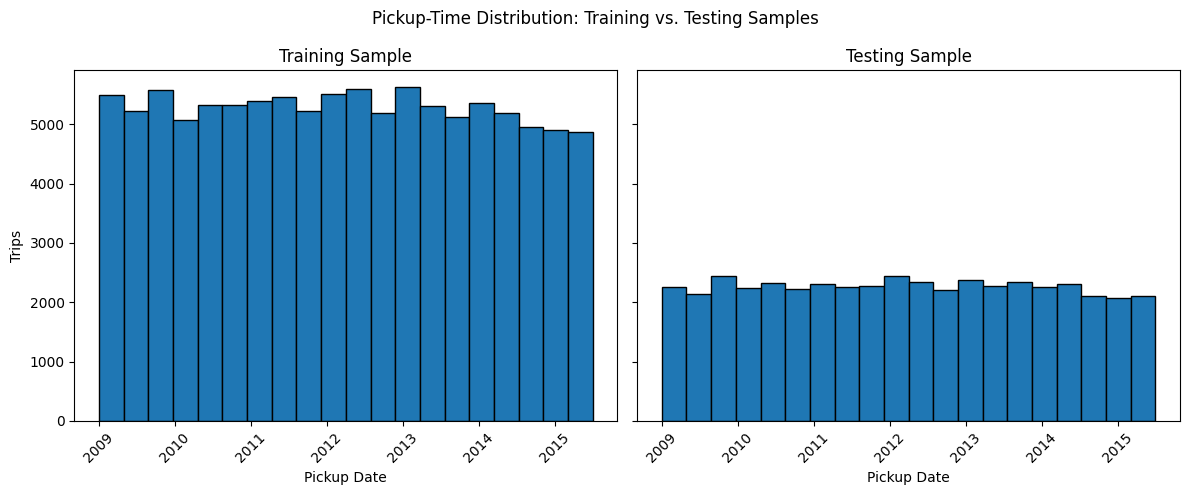

In [6]:
eda_train, eda_test = train_test_split(
    clean_data,
    test_size=0.30,
    random_state=RANDOM_STATE,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].hist(eda_train["pickup_datetime"], bins=20, edgecolor="black")
axes[0].set_title("Training Sample")
axes[0].set_xlabel("Pickup Date")
axes[0].set_ylabel("Trips")
axes[0].tick_params(axis="x", rotation=45)

axes[1].hist(eda_test["pickup_datetime"], bins=20, edgecolor="black")
axes[1].set_title("Testing Sample")
axes[1].set_xlabel("Pickup Date")
axes[1].tick_params(axis="x", rotation=45)

fig.suptitle("Pickup-Time Distribution: Training vs. Testing Samples")
plt.tight_layout()
plt.show()

### Pickup Location Heatmap

In [7]:
heatmap_sample = clean_data.sample(
    n=min(40_000, len(clean_data)),
    random_state=RANDOM_STATE,
)

pickup_map = folium.Map(
    location=[
        heatmap_sample["pickup_latitude"].mean(),
        heatmap_sample["pickup_longitude"].mean(),
    ],
    zoom_start=9,
)

heat_points = heatmap_sample[
    ["pickup_latitude", "pickup_longitude"]
].to_numpy().tolist()

HeatMap(heat_points).add_to(pickup_map)
display(pickup_map)

## 4. Feature Engineering

In [8]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two coordinate pairs in kilometers."""
    earth_radius_km = 6371.0

    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2],
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    return 2 * earth_radius_km * np.arcsin(np.sqrt(a))


model_data = clean_data.copy()

model_data["distance"] = haversine_distance(
    model_data["pickup_latitude"],
    model_data["pickup_longitude"],
    model_data["dropoff_latitude"],
    model_data["dropoff_longitude"],
)

model_data = model_data.assign(
    year=model_data["pickup_datetime"].dt.year,
    month=model_data["pickup_datetime"].dt.month,
    day=model_data["pickup_datetime"].dt.day,
    hour=model_data["pickup_datetime"].dt.hour,
    day_of_week=model_data["pickup_datetime"].dt.dayofweek,
)

model_data = model_data.drop(columns=["pickup_datetime", "key"])

display(model_data.head())

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance,year,month,day,hour,day_of_week
0,4.5,-73.844311,40.721319,-73.841610,40.712278,1,1.030764,2009,6,15,17,0
2,5.7,-73.982738,40.761270,-73.991242,40.750562,2,1.389525,2011,8,18,0,3
3,7.7,-73.987130,40.733143,-73.991567,40.758092,1,2.799270,2012,4,21,4,5
4,5.3,-73.968095,40.768008,-73.956655,40.783762,1,1.999157,2010,3,9,7,1
6,7.5,-73.980002,40.751662,-73.973802,40.764842,1,1.555807,2012,11,20,20,1


## 5. Train/Test Split

In [9]:
X = model_data.drop(columns="fare_amount")
y = model_data["fare_amount"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=1,
)

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows:  {len(X_test):,}")
print(f"Features:      {X_train.shape[1]}")

Training rows: 120,780
Testing rows:  30,196
Features:      11


## 6. Model Comparison

In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=1.0),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "LightGBM": lgb.LGBMRegressor(
        random_state=RANDOM_STATE,
        verbosity=-1,
    ),
}

model_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, predictions)

    model_results.append({
        "model": name,
        "rmse": rmse,
    })

results_df = (
    pd.DataFrame(model_results)
    .sort_values("rmse")
    .reset_index(drop=True)
)

display(results_df.style.format({"rmse": "{:.4f}"}))

best_model_name = results_df.loc[0, "model"]
best_model_rmse = results_df.loc[0, "rmse"]

print(f"Best baseline model: {best_model_name}")
print(f"Best baseline RMSE:  {best_model_rmse:.4f}")

,model,rmse
0,LightGBM,3.7660
1,XGBoost,3.8604
2,Gradient Boosting,4.0257
3,Random Forest,4.0366
4,Ridge Regression,5.1079
5,Linear Regression,5.1082
6,Lasso Regression,5.3102
7,Decision Tree,6.2858


Best baseline model: LightGBM
Best baseline RMSE:  3.7660


In the original run, **LightGBM** produced the lowest baseline RMSE at approximately **3.766**, ahead of XGBoost, Gradient Boosting, and Random Forest.

## 7. Feature Relationships and Importance

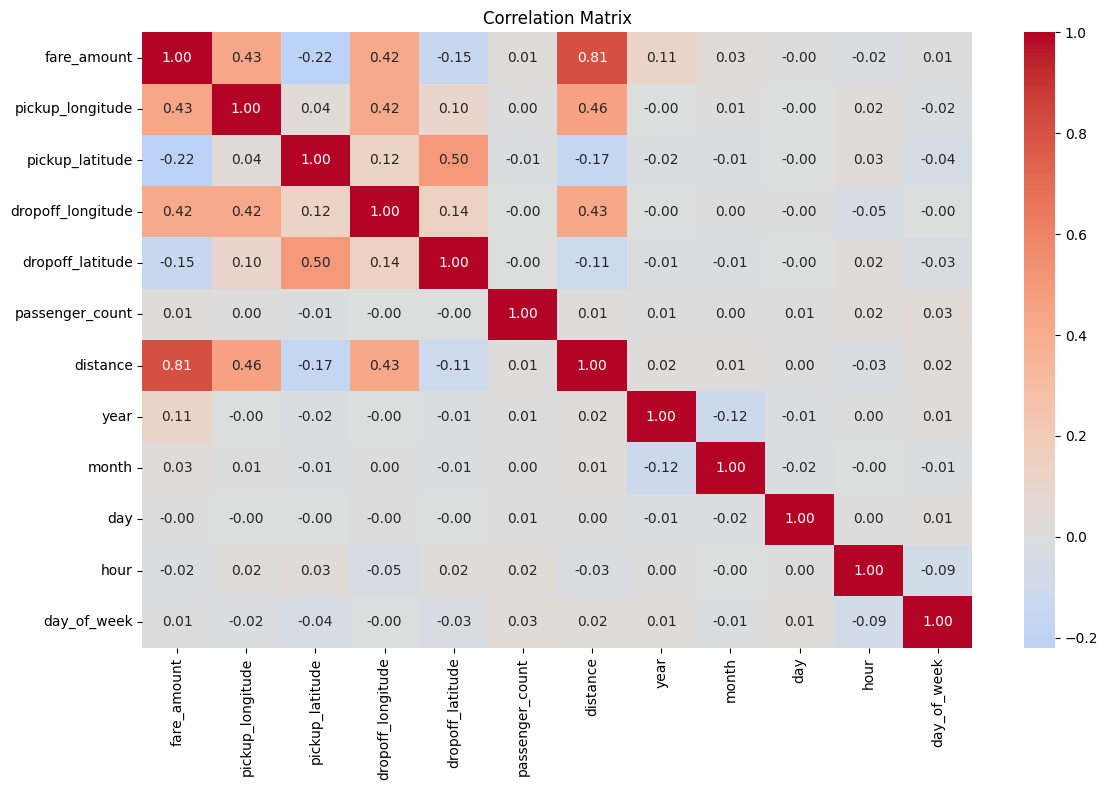

In [11]:
correlation_matrix = model_data.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [12]:
lasso_for_selection = Lasso(alpha=0.1)
lasso_for_selection.fit(X_train, y_train)

lasso_coefficients = (
    pd.DataFrame({
        "feature": X_train.columns,
        "coefficient": lasso_for_selection.coef_,
    })
    .query("coefficient != 0")
    .sort_values("coefficient", key=np.abs, ascending=False)
)

display(lasso_coefficients)

,feature,coefficient
5,distance,2.013642
6,year,0.490917
7,month,0.066718
10,day_of_week,-0.030181
9,hour,0.003669


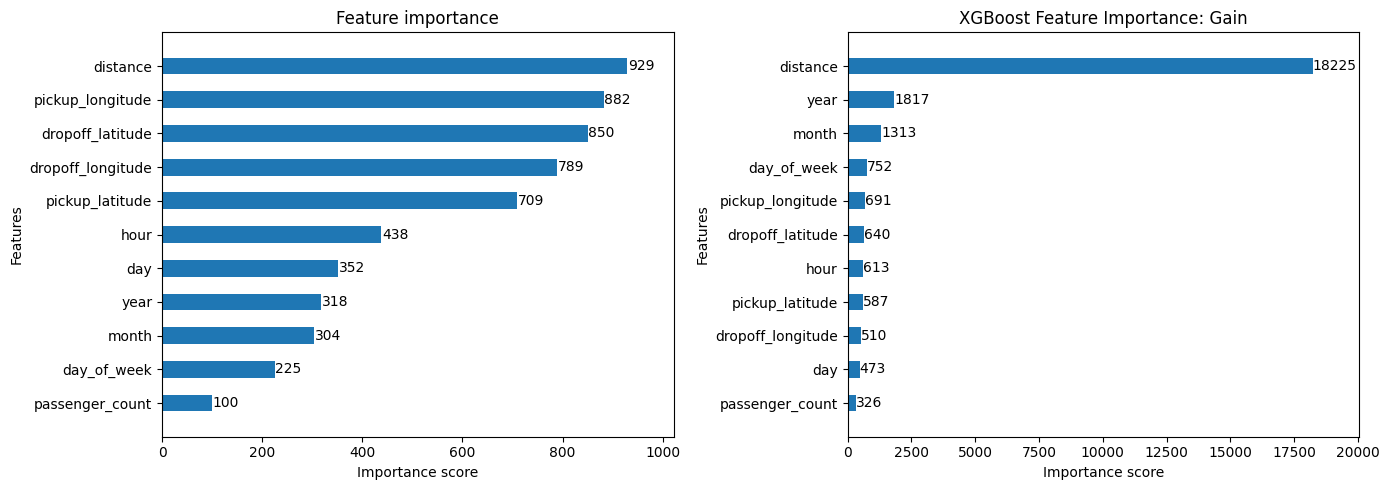

In [16]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_importance(
    xgb_model,
    importance_type="weight",
    ax=axes[0],
    height=0.5,
    values_format="{v:.0f}"
)

plot_importance(
    xgb_model,
    importance_type="gain",
    ax=axes[1],
    height=0.5,
    values_format="{v:.0f}"
)

axes[1].set_title("XGBoost Feature Importance: Gain")

axes[0].grid(False)
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 8. Selected-Feature LightGBM

In [17]:
important_features = [
    "distance",
    "year",
    "pickup_longitude",
    "dropoff_latitude",
    "pickup_latitude",
    "dropoff_longitude",
    "day",
    "hour",
    "month",
]

X_train_selected = X_train[important_features]
X_test_selected = X_test[important_features]

lgb_all = lgb.LGBMRegressor(
    random_state=RANDOM_STATE,
    verbosity=-1,
)
lgb_all.fit(X_train, y_train)

lgb_selected = lgb.LGBMRegressor(
    random_state=RANDOM_STATE,
    verbosity=-1,
)
lgb_selected.fit(X_train_selected, y_train)

rmse_all = root_mean_squared_error(
    y_test,
    lgb_all.predict(X_test),
)
rmse_selected = root_mean_squared_error(
    y_test,
    lgb_selected.predict(X_test_selected),
)

comparison = pd.DataFrame({
    "model": [
        "LightGBM - all features",
        "LightGBM - selected features",
    ],
    "rmse": [
        rmse_all,
        rmse_selected,
    ],
})

display(comparison.style.format({"rmse": "{:.4f}"}))

,model,rmse
0,LightGBM - all features,3.7660
1,LightGBM - selected features,3.7521


The original run produced:

- **All features:** RMSE ≈ **3.766**
- **Selected features:** RMSE ≈ **3.752**

The selected-feature model was slightly better while using fewer predictors.

## 9. Final Tuned LightGBM Model

The parameter values below are the best settings retained from the original project's tuning step. They are applied directly here so the final notebook remains concise and reproducible without rerunning an expensive parameter search every time.

In [18]:
best_params = {
    "learning_rate": 0.05,
    "max_depth": 20,
    "min_child_samples": 30,
    "n_estimators": 300,
    "num_leaves": 70,
}

final_model = lgb.LGBMRegressor(
    **best_params,
    random_state=RANDOM_STATE,
    verbosity=-1,
)

final_model.fit(X_train, y_train)
final_test_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(
    y_test,
    final_test_predictions,
)

print(f"Final tuned LightGBM RMSE: {final_rmse:.4f}")

Final tuned LightGBM RMSE: 3.7174


The original analysis achieved a final test RMSE of approximately **3.717**, which rounds to **3.72**.

## 10. Save Predictions

In [19]:
final_predictions = pd.DataFrame({
    "actual_fare": y_test.to_numpy(),
    "predicted_fare": np.round(final_test_predictions, 1),
})

PREDICTION_PATH = Path("final_fare_predictions.csv")
final_predictions.to_csv(PREDICTION_PATH, index=False)

print(f"Saved predictions to: {PREDICTION_PATH}")
display(final_predictions.head(10))

Saved predictions to: final_fare_predictions.csv


,actual_fare,predicted_fare
0,10.5,9.9
1,5.0,4.8
2,12.5,11.3
3,3.7,5.4
4,8.5,6.1
5,10.1,10.1
6,20.0,18.5
7,4.9,5.2
8,16.0,18.8
9,7.5,7.1


## 11. Conclusion

The analysis compared a range of linear, tree-based, boosting, and gradient-boosting models for Uber fare prediction. **Trip distance emerged as the most important predictive feature**, and LightGBM delivered the strongest performance.

The final tuned LightGBM model achieved a test RMSE of approximately **3.72**, improving on the baseline LightGBM model and demonstrating the value of feature engineering, model comparison, and hyperparameter optimization.